Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 55s 0us/step
Using 10000 training images and 2000 test images.
Extracting HOG features from training data... (This may take a minute)
Extracting HOG features from testing data...
Scaling features...
Training Linear SVM classifier...
Evaluating the model...

--- Classification Report ---
              precision    recall  f1-score   support

    airplane       0.47      0.52      0.49       196
  automobile       0.57      0.61      0.59       198
        bird       0.42      0.38      0.40       195
         cat       0.43      0.27      0.33       199
        deer       0.39      0.39      0.39       198
         dog       0.45      0.38      0.41       185
        frog       0.46      0.58      0.52       216
       horse       0.57      0.62      0.59       193
        ship       0.55      0.52      0.53       217
       truck       0.56      0.63      0.60       203

    accuracy                           0.49    

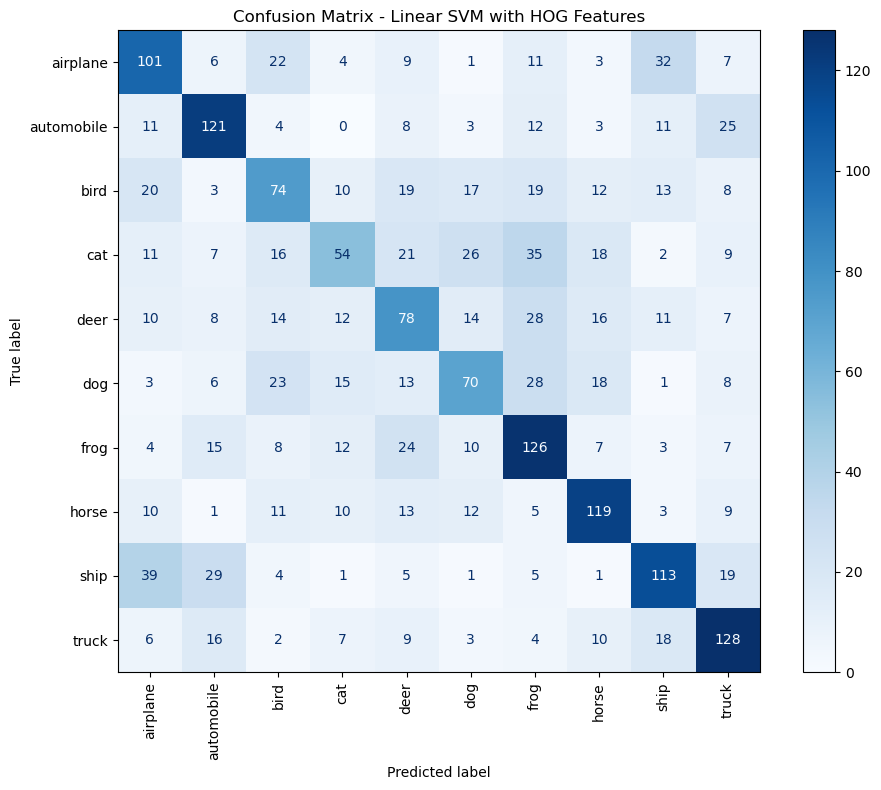

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from skimage.feature import hog
from skimage.color import rgb2gray
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# 1. Load the CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

# Flatten labels
y_train_full = y_train_full.flatten()
y_test_full = y_test_full.flatten()

# Class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# Subsample the dataset for faster local computation 
# (You can increase these numbers if your computer is fast enough)
train_size = 10000
test_size = 2000

x_train = x_train_full[:train_size]
y_train = y_train_full[:train_size]
x_test = x_test_full[:test_size]
y_test = y_test_full[:test_size]

print(f"Using {train_size} training images and {test_size} test images.")

# 2. Preprocessing & Feature Extraction (HOG)
def extract_hog_features(images):
    # Convert RGB images to Grayscale
    gray_images = rgb2gray(images)
    features = []
    for img in gray_images:
        # Extract Histogram of Oriented Gradients (HOG)
        fd = hog(img, orientations=9, pixels_per_cell=(8, 8),
                 cells_per_block=(2, 2), visualize=False)
        features.append(fd)
    return np.array(features)

print("Extracting HOG features from training data... (This may take a minute)")
x_train_features = extract_hog_features(x_train)

print("Extracting HOG features from testing data...")
x_test_features = extract_hog_features(x_test)

# Scale features for better SVM performance
print("Scaling features...")
scaler = StandardScaler()
x_train_features = scaler.fit_transform(x_train_features)
x_test_features = scaler.transform(x_test_features)

# 3. Model Training (Linear SVM)
print("Training Linear SVM classifier...")
clf = LinearSVC(random_state=42, max_iter=2000, dual=False)
clf.fit(x_train_features, y_train)

# 4. Evaluation
print("Evaluating the model...")
y_pred = clf.predict(x_test_features)

# Print Classification Report (Accuracy, Precision, Recall, F1-Score)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title("Confusion Matrix - Linear SVM with HOG Features")
plt.tight_layout()
plt.show()